### Import Libraries

In [1]:
# data manipulation & exploration
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Automated EDA
#!pip install sweetviz
import sweetviz as sv

# Regression Models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Ensembling
from sklearn.ensemble import VotingRegressor

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


# Evaluation metrics
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error, r2_score

from datetime import datetime
import time

### Time Start

In [2]:
start_all = time.time()

### Load 

In [3]:
# Read Data
t0 = time.time()
beijing_train = pd.read_csv('beijing_train.csv')
beijing_test = pd.read_csv('beijing_test.csv')
print(f'Data loaded in {round(time.time() - t0, 2)} seconds')

Data loaded in 0.49 seconds


In [4]:
#Check missing data
t0 = time.time()
missing_percent = round(beijing_train.isnull().mean() * 100, 2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Missing Value Percentage by Feature:")
print(missing_percent)

Missing Value Percentage by Feature:
CO       5.02
O3       3.22
NO2      2.94
SO2      2.17
PM2.5    2.10
PM10     1.54
wd       0.34
TEMP     0.07
PRES     0.07
DEWP     0.07
RAIN     0.06
WSPM     0.06
dtype: float64


In [5]:
missing_percent = round(beijing_test.isnull().mean() * 100, 2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Missing Value Percentage by Feature:")
print(missing_percent)
print(f'Missing values check in {round(time.time() - t0, 2)} seconds')

Missing Value Percentage by Feature:
Series([], dtype: float64)
Missing values check in 3.77 seconds


### Auto EDA

In [ ]:
"""# Auto EDA
eda_df = beijing_train.dropna(subset=['PM2.5'])

report = sv.analyze(eda_df, target_feat = 'PM2.5')
report.show_html('AQIPredTrain.html')

report = sv.compare([eda_df, 'Train'], [beijing_test, 'Test'])
report.show_html('AQIPredCompare.html')"""

### Impute Missing values using MEAN & MODE

In [6]:
t0 = time.time()
# Get numeric columns
numeric_cols = beijing_train.select_dtypes(include=[np.number]).columns

# Filter numeric columns that have missing values
numeric_missing_cols = [col for col in numeric_cols if beijing_train[col].isnull().any()]

# Impute missing values in those columns with mean
beijing_train[numeric_missing_cols] = beijing_train[numeric_missing_cols].fillna(beijing_train[numeric_missing_cols].mean())

# Impute missing values in 'wd' with its mode
beijing_train['wd'] = beijing_train['wd'].fillna(beijing_train['wd'].mode()[0])

print(f'Missing values check in {round(time.time() - t0, 2)} seconds')

Missing values check in 0.17 seconds


In [7]:
beijing_train.drop(['REF_NO'], axis = 1, inplace = True)

### Feature Engineering

In [8]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

In [9]:
wd_mapping = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
    'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225,
    'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

In [10]:
t0 = time.time()
# Combine year, month, day, hour into a datetime column
beijing_train['datetime'] = pd.to_datetime(beijing_train[['year', 'month', 'day', 'hour']])
beijing_test['datetime'] = pd.to_datetime(beijing_test[['year', 'month', 'day', 'hour']])

# Day of week feature
beijing_train['dayofweek'] = beijing_train['datetime'].dt.dayofweek
beijing_test['dayofweek'] = beijing_test['datetime'].dt.dayofweek

# Is or not weekend feature
beijing_train['is_weekend'] = beijing_train['dayofweek'].isin([5, 6]).astype(int)
beijing_test['is_weekend'] = beijing_test['dayofweek'].isin([5, 6]).astype(int)

# Season feature
beijing_train['season'] = beijing_train['month'].apply(get_season)
beijing_test['season'] = beijing_test['month'].apply(get_season)

# One-hot encode season
beijing_train = pd.get_dummies(beijing_train, columns=['season'], drop_first=True)
beijing_test = pd.get_dummies(beijing_test, columns=['season'], drop_first=True)

#Sine-Cosine Transform of Hour to capture Cyclicality
beijing_train['hour_sin'] = np.sin(2 * np.pi * beijing_train['hour'] / 24)
beijing_train['hour_cos'] = np.cos(2 * np.pi * beijing_train['hour'] / 24)

beijing_test['hour_sin'] = np.sin(2 * np.pi * beijing_test['hour'] / 24)
beijing_test['hour_cos'] = np.cos(2 * np.pi * beijing_test['hour'] / 24)

# PM10 lag feature
beijing_train['PM10_lag1'] = beijing_train['PM10'].shift(1)
beijing_train['PM10_lag2'] = beijing_train['PM10'].shift(2)
beijing_test['PM10_lag1'] = beijing_test['PM10'].shift(1)
beijing_test['PM10_lag2'] = beijing_test['PM10'].shift(2)

# Fillna of missing values in lag features
beijing_train['PM10_lag1'] = beijing_train['PM10'].shift(1).fillna(0)
beijing_train['PM10_lag2'] = beijing_train['PM10'].shift(2).fillna(0)
beijing_test['PM10_lag1'] = beijing_test['PM10'].shift(1).fillna(0)
beijing_test['PM10_lag2'] = beijing_test['PM10'].shift(2).fillna(0)

# Average PM10 feature by station
beijing_train['StationAvgPM10'] = beijing_train.groupby('station')['PM10'].transform('mean')
beijing_test['StationAvgPM10'] = beijing_test.groupby('station')['PM10'].transform('mean')

# Wind angle & Sine-cosine feature
beijing_train['wd_angle'] = beijing_train['wd'].map(wd_mapping)
beijing_train['wd_sin'] = np.sin(np.deg2rad(beijing_train['wd_angle']))
beijing_train['wd_cos'] = np.cos(np.deg2rad(beijing_train['wd_angle']))

beijing_test['wd_angle'] = beijing_test['wd'].map(wd_mapping)
beijing_test['wd_sin'] = np.sin(np.deg2rad(beijing_test['wd_angle']))
beijing_test['wd_cos'] = np.cos(np.deg2rad(beijing_test['wd_angle']))

# One-hot encode 'station' and 'wd'
beijing_train_encoded = pd.get_dummies(beijing_train, columns=['station', 'wd'], drop_first=True)
beijing_test_encoded = pd.get_dummies(beijing_test, columns=['station', 'wd'], drop_first=True)

# Interaction features
beijing_train_encoded['NO2_SO2'] = beijing_train_encoded['NO2'] * beijing_train_encoded['SO2']
beijing_test_encoded['NO2_SO2'] = beijing_test_encoded['NO2'] * beijing_test_encoded['SO2']

beijing_train_encoded['TEMP_WSPM'] = beijing_train_encoded['TEMP'] * beijing_train_encoded['WSPM']
beijing_test_encoded['TEMP_WSPM'] = beijing_test_encoded['TEMP'] * beijing_test_encoded['WSPM']

beijing_train_encoded['PM10_O3'] = beijing_train_encoded['PM10'] * beijing_train_encoded['O3']
beijing_test_encoded['PM10_O3'] = beijing_test_encoded['PM10'] * beijing_test_encoded['O3']

# Pollution index features
pollutants = ['PM10', 'SO2', 'NO2', 'CO', 'O3']
beijing_train_encoded['PollutionIndex'] = beijing_train_encoded[pollutants].mean(axis=1)
beijing_test_encoded['PollutionIndex'] = beijing_test_encoded[pollutants].mean(axis=1)

# Humidity feature
beijing_train_encoded['Humidity'] = 100 * (
    np.exp((17.625 * beijing_train_encoded['DEWP']) / (243.04 + beijing_train_encoded['DEWP'])) /
    np.exp((17.625 * beijing_train_encoded['TEMP']) / (243.04 + beijing_train_encoded['TEMP']))
)
beijing_test_encoded['Humidity'] = 100 * (
    np.exp((17.625 * beijing_test_encoded['DEWP']) / (243.04 + beijing_test_encoded['DEWP'])) /
    np.exp((17.625 * beijing_test_encoded['TEMP']) / (243.04 + beijing_test_encoded['TEMP']))
)

# Windchill feature
wind_speed_kmh_train = beijing_train_encoded['WSPM'] * 3.6
wind_speed_kmh_test = beijing_test_encoded['WSPM'] * 3.6

beijing_train_encoded['WindChill'] = (
    13.12 + 0.6215 * beijing_train_encoded['TEMP'] - 11.37 * wind_speed_kmh_train**0.16 +
    0.3965 * beijing_train_encoded['TEMP'] * wind_speed_kmh_train**0.16
)
beijing_test_encoded['WindChill'] = (
    13.12 + 0.6215 * beijing_test_encoded['TEMP'] - 11.37 * wind_speed_kmh_test**0.16 +
    0.3965 * beijing_test_encoded['TEMP'] * wind_speed_kmh_test**0.16
)

# Delta features
weather_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for var in weather_vars:
    beijing_train_encoded[f'{var}_delta'] = beijing_train_encoded[var].diff()

for var in weather_vars:
    beijing_test_encoded[f'{var}_delta'] = beijing_test_encoded[var].diff()

beijing_train_encoded[['TEMP_delta', 'PRES_delta', 'DEWP_delta', 'RAIN_delta', 'WSPM_delta']] = beijing_train_encoded[['TEMP_delta', 'PRES_delta', 'DEWP_delta', 'RAIN_delta', 'WSPM_delta']].fillna(0)
beijing_test_encoded[['TEMP_delta', 'PRES_delta', 'DEWP_delta', 'RAIN_delta', 'WSPM_delta']] = beijing_test_encoded[['TEMP_delta', 'PRES_delta', 'DEWP_delta', 'RAIN_delta', 'WSPM_delta']].fillna(0)

print(f'Feature engineering in {round(time.time() - t0, 2)} seconds')

Feature engineering in 0.72 seconds


In [11]:
# Ensure both train and test have the same one-hot encoded columns (excluding target and datetime)
common_cols = [col for col in beijing_train_encoded.columns 
               if col != 'PM2.5' and col != 'datetime']

# Reindex test to match train columns
beijing_test_encoded = beijing_test_encoded.reindex(columns=common_cols, fill_value=0)

# Drop target from test set if present
beijing_test_encoded = beijing_test_encoded.drop(columns=['PM2.5'], errors='ignore')

### Correlation check

In [12]:
beijing_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403776 entries, 0 to 403775
Data columns (total 66 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   year                   403776 non-null  int64         
 1   month                  403776 non-null  int64         
 2   day                    403776 non-null  int64         
 3   hour                   403776 non-null  int64         
 4   PM2.5                  403776 non-null  float64       
 5   PM10                   403776 non-null  float64       
 6   SO2                    403776 non-null  float64       
 7   NO2                    403776 non-null  float64       
 8   CO                     403776 non-null  float64       
 9   O3                     403776 non-null  float64       
 10  TEMP                   403776 non-null  float64       
 11  PRES                   403776 non-null  float64       
 12  DEWP                   403776 non-null  floa

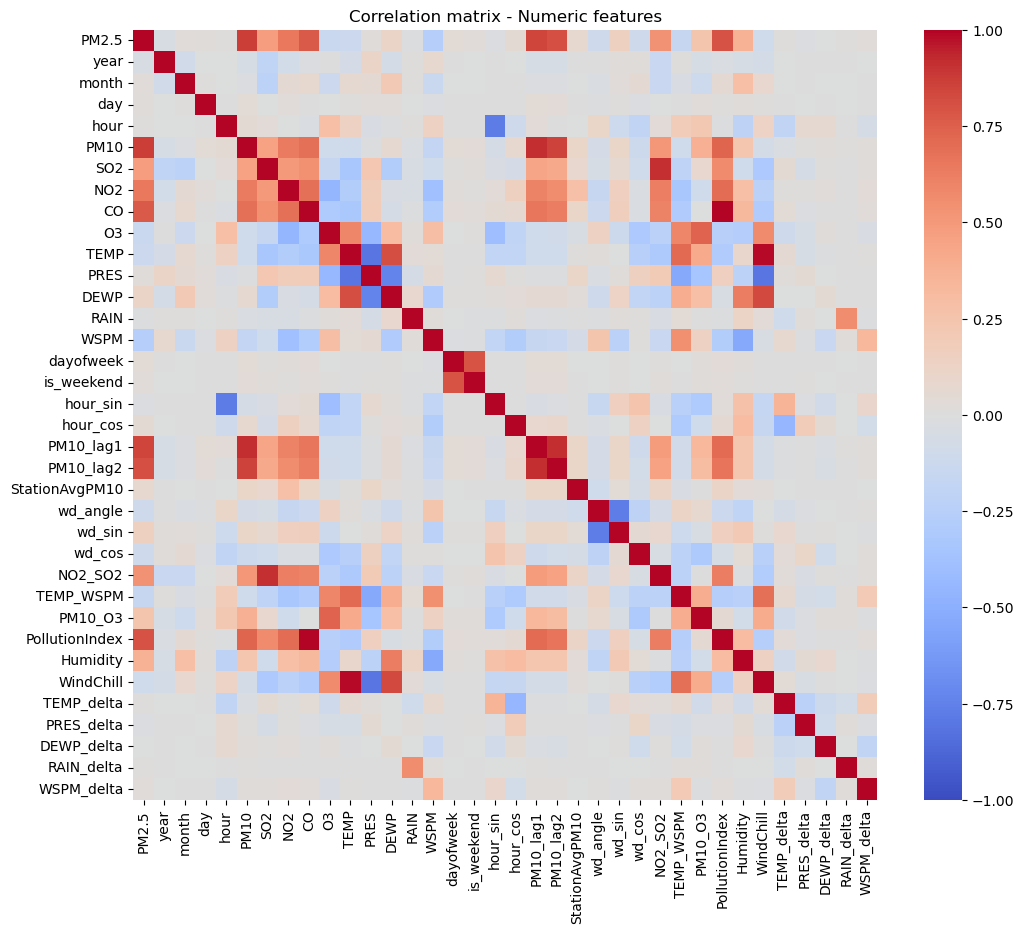

Correlation plot in 1.6 seconds


In [14]:
t0 = time.time()
numeric_features=['PM2.5', 'year', 'month', 'day', 'hour', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                  'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'PM10_lag1', 'PM10_lag2',
                 'StationAvgPM10', 'wd_angle', 'wd_sin', 'wd_cos',
                 'NO2_SO2', 'TEMP_WSPM', 'PM10_O3', 'PollutionIndex', 'Humidity', 'WindChill',
                 'TEMP_delta', 'PRES_delta', 'DEWP_delta', 'RAIN_delta', 'WSPM_delta']

# Correlation matrix
corr = beijing_train_encoded[numeric_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot = False, fmt ='.2f', cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation matrix - Numeric features')
plt.show()
print(f'Correlation plot in {round(time.time() - t0, 2)} seconds')

In [15]:
# Check for missing values
print("Missing values in training data:")
print(beijing_train_encoded.isnull().sum()[beijing_train_encoded.isnull().sum() > 0])

print("\nRows with missing values in training data:")
print(beijing_train_encoded[beijing_train_encoded.isnull().any(axis=1)])

print("\nMissing values in test data:")
print(beijing_test_encoded.isnull().sum()[beijing_test_encoded.isnull().sum() > 0])

print("\nRows with missing values in test data:")
print(beijing_test_encoded[beijing_test_encoded.isnull().any(axis=1)])

Missing values in training data:
Series([], dtype: int64)

Rows with missing values in training data:
Empty DataFrame
Columns: [year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM, datetime, dayofweek, is_weekend, season_spring, season_summer, season_winter, hour_sin, hour_cos, PM10_lag1, PM10_lag2, StationAvgPM10, wd_angle, wd_sin, wd_cos, station_Changping, station_Dingling, station_Dongsi, station_Guanyuan, station_Gucheng, station_Huairou, station_Nongzhanguan, station_Shunyi, station_Tiantan, station_Wanliu, station_Wanshouxigong, wd_ENE, wd_ESE, wd_N, wd_NE, wd_NNE, wd_NNW, wd_NW, wd_S, wd_SE, wd_SSE, wd_SSW, wd_SW, wd_W, wd_WNW, wd_WSW, NO2_SO2, TEMP_WSPM, PM10_O3, PollutionIndex, Humidity, WindChill, TEMP_delta, PRES_delta, DEWP_delta, RAIN_delta, WSPM_delta]
Index: []

[0 rows x 66 columns]

Missing values in test data:
Series([], dtype: int64)

Rows with missing values in test data:
Empty DataFrame
Columns: [year, month, day, hour, PM10, SO2, N

### Creating dataframes for prediction

In [16]:
t0 = time.time()
# Define features and target
X = beijing_train_encoded.drop(columns=['PM2.5'])
y = beijing_train_encoded['PM2.5']

# Split train data based on year
train_data = beijing_train_encoded[beijing_train_encoded['year'] < 2016]
val_data = beijing_train_encoded[beijing_train_encoded['year'] == 2016]

# Define features and target
X_train = train_data.drop(columns=['PM2.5'])
y_train = train_data['PM2.5']
X_val = val_data.drop(columns=['PM2.5'])
y_val = val_data['PM2.5']

# Drop non-numeric columns like 'datetime' before training
X_train_model = X_train.select_dtypes(include=[np.number])
X_val_model = X_val.select_dtypes(include=[np.number])

print(f'Dataframe creation in {round(time.time() - t0, 2)} seconds')

Dataframe creation in 0.3 seconds


### Voting Regressor & Validation Check

In [19]:
t0 = time.time()
# Models
catboost_model = CatBoostRegressor()
xgb = XGBRegressor()

#Voting Regressor
voting_model = VotingRegressor(
    estimators=[
        ('catboost', catboost_model),
        ('xgb', xgb)
    ]
)
voting_model.fit(X_train_model, y_train)
voting_preds = voting_model.predict(X_val_model)

rmse = root_mean_squared_error(y_val, voting_preds)
r2 = r2_score(y_val, voting_preds)
mape = mean_absolute_percentage_error(y_val, voting_preds) * 100  # Convert to percentage

print("Voting Regressor:")

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")
print(f"Validation MAPE: {mape:.2f}%")
print(f'Validation in {round(time.time() - t0, 2)} seconds')

Learning rate set to 0.100737
0:	learn: 72.9607284	total: 26.5ms	remaining: 26.5s
1:	learn: 67.2612672	total: 48.9ms	remaining: 24.4s
2:	learn: 62.2319876	total: 71.6ms	remaining: 23.8s
3:	learn: 57.7245156	total: 94.3ms	remaining: 23.5s
4:	learn: 53.6869015	total: 118ms	remaining: 23.5s
5:	learn: 50.0590329	total: 141ms	remaining: 23.3s
6:	learn: 46.9210628	total: 164ms	remaining: 23.2s
7:	learn: 44.1620216	total: 188ms	remaining: 23.3s
8:	learn: 41.7340638	total: 213ms	remaining: 23.5s
9:	learn: 39.5755259	total: 236ms	remaining: 23.3s
10:	learn: 37.7047962	total: 258ms	remaining: 23.2s
11:	learn: 36.0836836	total: 280ms	remaining: 23.1s
12:	learn: 34.6304642	total: 303ms	remaining: 23s
13:	learn: 33.3794073	total: 325ms	remaining: 22.9s
14:	learn: 32.3160496	total: 347ms	remaining: 22.8s
15:	learn: 31.3817185	total: 370ms	remaining: 22.7s
16:	learn: 30.5441319	total: 391ms	remaining: 22.6s
17:	learn: 29.8404797	total: 419ms	remaining: 22.9s
18:	learn: 29.2144790	total: 447ms	remaini

163:	learn: 20.4582650	total: 3.88s	remaining: 19.8s
164:	learn: 20.4413852	total: 3.92s	remaining: 19.9s
165:	learn: 20.4268691	total: 3.96s	remaining: 19.9s
166:	learn: 20.4060780	total: 3.99s	remaining: 19.9s
167:	learn: 20.3957943	total: 4.02s	remaining: 19.9s
168:	learn: 20.3838790	total: 4.05s	remaining: 19.9s
169:	learn: 20.3731091	total: 4.08s	remaining: 19.9s
170:	learn: 20.3605647	total: 4.12s	remaining: 20s
171:	learn: 20.3488099	total: 4.15s	remaining: 20s
172:	learn: 20.3335077	total: 4.18s	remaining: 20s
173:	learn: 20.3218554	total: 4.2s	remaining: 19.9s
174:	learn: 20.3093991	total: 4.23s	remaining: 19.9s
175:	learn: 20.2964102	total: 4.26s	remaining: 19.9s
176:	learn: 20.2838592	total: 4.29s	remaining: 19.9s
177:	learn: 20.2681893	total: 4.32s	remaining: 19.9s
178:	learn: 20.2565557	total: 4.35s	remaining: 19.9s
179:	learn: 20.2446031	total: 4.38s	remaining: 20s
180:	learn: 20.2330277	total: 4.41s	remaining: 20s
181:	learn: 20.2197882	total: 4.44s	remaining: 20s
182:	l

322:	learn: 18.7405677	total: 8.03s	remaining: 16.8s
323:	learn: 18.7345896	total: 8.06s	remaining: 16.8s
324:	learn: 18.7244695	total: 8.08s	remaining: 16.8s
325:	learn: 18.7210311	total: 8.1s	remaining: 16.8s
326:	learn: 18.7151696	total: 8.13s	remaining: 16.7s
327:	learn: 18.7071003	total: 8.15s	remaining: 16.7s
328:	learn: 18.7006924	total: 8.18s	remaining: 16.7s
329:	learn: 18.6904850	total: 8.21s	remaining: 16.7s
330:	learn: 18.6859684	total: 8.22s	remaining: 16.6s
331:	learn: 18.6783362	total: 8.25s	remaining: 16.6s
332:	learn: 18.6702620	total: 8.27s	remaining: 16.6s
333:	learn: 18.6643323	total: 8.29s	remaining: 16.5s
334:	learn: 18.6565789	total: 8.31s	remaining: 16.5s
335:	learn: 18.6483732	total: 8.34s	remaining: 16.5s
336:	learn: 18.6395464	total: 8.37s	remaining: 16.5s
337:	learn: 18.6320580	total: 8.39s	remaining: 16.4s
338:	learn: 18.6235224	total: 8.42s	remaining: 16.4s
339:	learn: 18.6192064	total: 8.45s	remaining: 16.4s
340:	learn: 18.6122008	total: 8.48s	remaining: 

486:	learn: 17.7481186	total: 12s	remaining: 12.6s
487:	learn: 17.7428461	total: 12s	remaining: 12.6s
488:	learn: 17.7339048	total: 12s	remaining: 12.5s
489:	learn: 17.7274480	total: 12s	remaining: 12.5s
490:	learn: 17.7229965	total: 12.1s	remaining: 12.5s
491:	learn: 17.7205808	total: 12.1s	remaining: 12.5s
492:	learn: 17.7159360	total: 12.1s	remaining: 12.4s
493:	learn: 17.7120227	total: 12.1s	remaining: 12.4s
494:	learn: 17.7074435	total: 12.1s	remaining: 12.4s
495:	learn: 17.7029759	total: 12.2s	remaining: 12.4s
496:	learn: 17.6968459	total: 12.2s	remaining: 12.3s
497:	learn: 17.6906637	total: 12.2s	remaining: 12.3s
498:	learn: 17.6854431	total: 12.2s	remaining: 12.3s
499:	learn: 17.6815474	total: 12.3s	remaining: 12.3s
500:	learn: 17.6738349	total: 12.3s	remaining: 12.3s
501:	learn: 17.6664259	total: 12.3s	remaining: 12.2s
502:	learn: 17.6626086	total: 12.3s	remaining: 12.2s
503:	learn: 17.6549826	total: 12.4s	remaining: 12.2s
504:	learn: 17.6531251	total: 12.4s	remaining: 12.1s
5

645:	learn: 17.0309255	total: 15.9s	remaining: 8.69s
646:	learn: 17.0251806	total: 15.9s	remaining: 8.67s
647:	learn: 17.0226156	total: 15.9s	remaining: 8.65s
648:	learn: 17.0204688	total: 15.9s	remaining: 8.63s
649:	learn: 17.0145612	total: 16s	remaining: 8.61s
650:	learn: 17.0115560	total: 16s	remaining: 8.59s
651:	learn: 17.0071039	total: 16s	remaining: 8.56s
652:	learn: 17.0034540	total: 16.1s	remaining: 8.54s
653:	learn: 16.9984851	total: 16.1s	remaining: 8.53s
654:	learn: 16.9959692	total: 16.1s	remaining: 8.5s
655:	learn: 16.9929977	total: 16.2s	remaining: 8.48s
656:	learn: 16.9877608	total: 16.2s	remaining: 8.46s
657:	learn: 16.9864151	total: 16.2s	remaining: 8.44s
658:	learn: 16.9857884	total: 16.3s	remaining: 8.41s
659:	learn: 16.9840265	total: 16.3s	remaining: 8.39s
660:	learn: 16.9810576	total: 16.3s	remaining: 8.36s
661:	learn: 16.9781409	total: 16.3s	remaining: 8.34s
662:	learn: 16.9772426	total: 16.4s	remaining: 8.31s
663:	learn: 16.9734106	total: 16.4s	remaining: 8.29s


801:	learn: 16.4722843	total: 19.8s	remaining: 4.88s
802:	learn: 16.4707091	total: 19.8s	remaining: 4.86s
803:	learn: 16.4680820	total: 19.8s	remaining: 4.83s
804:	learn: 16.4638152	total: 19.9s	remaining: 4.81s
805:	learn: 16.4601374	total: 19.9s	remaining: 4.79s
806:	learn: 16.4573362	total: 19.9s	remaining: 4.77s
807:	learn: 16.4541073	total: 20s	remaining: 4.74s
808:	learn: 16.4503660	total: 20s	remaining: 4.72s
809:	learn: 16.4473295	total: 20s	remaining: 4.7s
810:	learn: 16.4456543	total: 20s	remaining: 4.67s
811:	learn: 16.4436412	total: 20.1s	remaining: 4.65s
812:	learn: 16.4383149	total: 20.1s	remaining: 4.63s
813:	learn: 16.4355844	total: 20.1s	remaining: 4.6s
814:	learn: 16.4299379	total: 20.2s	remaining: 4.58s
815:	learn: 16.4258183	total: 20.2s	remaining: 4.55s
816:	learn: 16.4227009	total: 20.3s	remaining: 4.54s
817:	learn: 16.4190475	total: 20.3s	remaining: 4.52s
818:	learn: 16.4174213	total: 20.4s	remaining: 4.5s
819:	learn: 16.4143237	total: 20.4s	remaining: 4.49s
820:

962:	learn: 16.0292929	total: 24.4s	remaining: 936ms
963:	learn: 16.0279741	total: 24.4s	remaining: 910ms
964:	learn: 16.0245311	total: 24.4s	remaining: 885ms
965:	learn: 16.0223622	total: 24.4s	remaining: 860ms
966:	learn: 16.0190460	total: 24.5s	remaining: 834ms
967:	learn: 16.0167259	total: 24.5s	remaining: 809ms
968:	learn: 16.0149369	total: 24.5s	remaining: 784ms
969:	learn: 16.0112539	total: 24.5s	remaining: 759ms
970:	learn: 16.0085807	total: 24.5s	remaining: 733ms
971:	learn: 16.0053515	total: 24.6s	remaining: 708ms
972:	learn: 16.0027474	total: 24.6s	remaining: 683ms
973:	learn: 15.9978416	total: 24.6s	remaining: 657ms
974:	learn: 15.9958935	total: 24.7s	remaining: 632ms
975:	learn: 15.9955636	total: 24.7s	remaining: 607ms
976:	learn: 15.9913431	total: 24.7s	remaining: 581ms
977:	learn: 15.9892044	total: 24.7s	remaining: 556ms
978:	learn: 15.9858825	total: 24.7s	remaining: 531ms
979:	learn: 15.9831197	total: 24.8s	remaining: 506ms
980:	learn: 15.9780001	total: 24.8s	remaining:

### Predictions vs Actuals

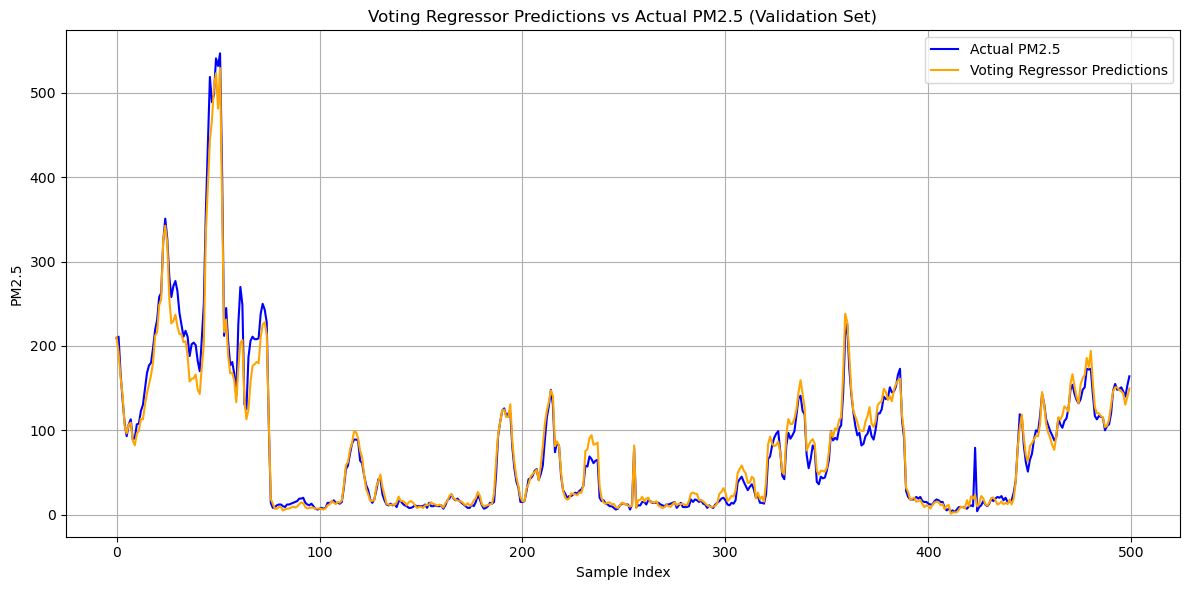

Plot in 0.3 seconds


In [20]:
t0 = time.time()
# Line plot: Predictions vs Actuals
plt.figure(figsize=(12, 6))
plt.plot(y_val.values[:500], label='Actual PM2.5', color='blue')
plt.plot(voting_preds[:500], label='Voting Regressor Predictions', color='orange')
plt.xlabel("Sample Index")
plt.ylabel("PM2.5")
plt.title("Voting Regressor Predictions vs Actual PM2.5 (Validation Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("voting_vs_actuals.png")  # Optional: Save the plot
plt.show()
print(f'Plot in {round(time.time() - t0, 2)} seconds')

### Test Predictions & Submission File

In [24]:
t0 = time.time()
beijing_test = pd.read_csv('beijing_test.csv')
X_test_model = beijing_test_encoded.reindex(columns=X_train_model.columns, fill_value=0)
voting_preds_test = voting_model.predict(X_test_model)
submission = pd.DataFrame({
    'REF_NO': beijing_test['REF_NO'],
    'PM2.5': voting_preds_test
})
submission.to_csv("submission.csv", index=False)
print(f'Predictions in {round(time.time() - t0, 2)} seconds')

Predictions in 0.13 seconds
